# Análise de Tráfego de Rede 2025/26 
## TP3 - Redução de Dimensionalidade e Classificação ML


### Grupo 04

<p style="font-size: 0.9em;">
Carlos Daniel Silva Fernandes - PG59783
</p>

<p style="font-size: 0.9em;">
Luís Filipe Pinheiro Silva - PG59790
</p>


<p style="font-size: 0.9em;">
Pedro Augusto Ennes de Martino Camargo - PG59791
</p>

---

## Introdução

O presente relatório tem como objetivo a análise do impacto da redução de dimensionalidade no treino de modelos de machine learning em aprendizagem supervisionada. É ainda utilizado um modelo em aprendizagem não-supervisionada para deteção de anomalias.

Começamos por fazer um tratamento e análise do dataset usado, utilizando as seguintes ferramentas:

   - **NFStream**: o NFStream é utilizado para extrair os fluxos presentes nos pcaps que compõe o dataset, permitindo agrupar vários pacotes num só fluxo.

   - **thsark**: o tshark é utilizado para uma análise mais detalhada, permitindo-nos recolher dados especíicos a cada pacote, tal como as assinaturas JA3 e JA3s.

Durante esta análise é atribuído a cada fluxo uma `'label'` que serve para os categorizar como tráfego benigno, malicioso ou VPN/Tor.

`Nota:`
Neste trabalho foi usado o JA3 e JA3s invés do JA4 e JA4s por nos basearmos nos slides dedicados a este TP3.

### Tratamento dos dados

In [1]:
from nfstream import NFStreamer
import subprocess
import pandas as pd
import glob

df_anomaly = pd.read_csv("pcaps/20240702_anomalous_suspicious.csv")
df_anomaly.columns = df_anomaly.columns.str.strip()

def build_ip_port_sets(df, label):
    entries = set()
    subset = df[df["label"] == label]
    for _, row in subset.iterrows():
        src_ip   = str(row["srcIP"])   if pd.notna(row["srcIP"])   else None
        dst_ip   = str(row["dstIP"])   if pd.notna(row["dstIP"])   else None
        src_port = str(row["srcPort"]) if pd.notna(row["srcPort"]) else None
        dst_port = str(row["dstPort"]) if pd.notna(row["dstPort"]) else None

        
        if src_ip and src_port:
            entries.add((src_ip, src_port))
        if dst_ip and dst_port:
            entries.add((dst_ip, dst_port))
        
        if src_ip and not src_port:
            entries.add((src_ip, None))
        if dst_ip and not dst_port:
            entries.add((dst_ip, None))
    return entries

def flow_matches(ip, port, entries):
    port_str = str(int(float(port))) if pd.notna(port) and port != "" else None
    ip_str   = str(ip) if pd.notna(ip) else None

    if not ip_str:
        return False

    if port_str and (ip_str, port_str) in entries:
        return True
    
    if (ip_str, None) in entries:
        return True
    return False

def assign_label(row):
    if row["label"] in ["benign", "vpn"]:
        return row["label"]

    src_ip   = row.get("src_ip_x", "")
    dst_ip   = row.get("dst_ip_x", "")
    src_port = row.get("src_port_x", "")
    dst_port = row.get("dst_port_x", "")

    if flow_matches(src_ip, src_port, anomalous_entries) or \
       flow_matches(dst_ip, dst_port, anomalous_entries):
        return "malicious"

    if flow_matches(src_ip, src_port, suspicious_entries) or \
       flow_matches(dst_ip, dst_port, suspicious_entries):
        return "malicious"

    return "benign"

pcaps = {}

for pcap_file in glob.glob("pcaps/vpn/*.pcap") + glob.glob("pcaps/vpn/*.pcapng"):
    pcaps[pcap_file] = "vpn"

for pcap_file in glob.glob("pcaps/normal/*.pcap") + glob.glob("pcaps/normal/*.pcapng"):
    pcaps[pcap_file] = "benign"

pcaps["pcaps/202407021400_trimmed.pcap"] ="unknown"

all_data = []

for pcap, label in pcaps.items():
    print(f"A processar {pcap} do tipo '{label}'...")
    streamer = NFStreamer(source=pcap)
    df_flows = streamer.to_pandas()

    df_flows["flow_key"] = (
        df_flows["src_ip"] + "_" +
        df_flows["dst_ip"] + "_" +
        df_flows["src_port"].astype(str) + "_" +
        df_flows["dst_port"].astype(str) + "_" +
        df_flows["protocol"].astype(str)
    )

    df_flows["label"] = label

    tshark_call = [
        "tshark",
        "-r", pcap,
        "-Y", "tls.handshake.type == 1 || tls.handshake.type == 2",
        "-T", "fields",
        "-e", "frame.time",
        "-e", "ip.src",
        "-e", "ip.dst",
        "-e", "tcp.srcport",
        "-e", "tcp.dstport",
        "-e", "tls.handshake.type",
        "-e", "tls.handshake.ja3",
        "-e", "tls.handshake.ja3s",
        "-e", "tls.handshake.extensions_server_name",
        "-e", "tcp.stream",
    ]

    proc = subprocess.Popen(tshark_call, stdout=subprocess.PIPE, text=True)

    df_ja3 = pd.read_csv(
        proc.stdout,
        sep="\t",
        names=[
            "time", "src_ip", "dst_ip",
            "src_port", "dst_port",
            "type", "ja3", "ja3s",
            "extensions_server_name", "stream"
        ]
    )

    df_ja3["flow_key"] = (
        df_ja3["src_ip"] + "_" +
        df_ja3["dst_ip"] + "_" +
        df_ja3["src_port"].astype(str) + "_" +
        df_ja3["dst_port"].astype(str) + "_6"
    )

    df = pd.merge(df_flows, df_ja3, on="flow_key", how="left")
    all_data.append(df)

all_data_clean = [df for df in all_data if not df.empty and not df.isna().all().all()]
df_final = pd.concat(all_data_clean, ignore_index=True)

suspicious_entries = build_ip_port_sets(df_anomaly, "suspicious")
anomalous_entries  = build_ip_port_sets(df_anomaly, "anomalous")

df_final["label"] = df_final.apply(assign_label, axis=1)

df_final["label"].value_counts()

A processar pcaps/vpn/vpn_ftps_A.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_facebook_audio2.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_email2a.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_email2b.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_facebook_chat1a.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_hangouts_chat1a.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_ftps_B.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_hangouts_audio2.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_facebook_chat1b.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_hangouts_audio1.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_hangouts_chat1b.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_aim_chat1b.pcap do tipo 'vpn'...
A processar pcaps/vpn/vpn_aim_chat1a.pcap do tipo 'vpn'...
A processar pcaps/normal/facebook_audio2a.pcap do tipo 'benign'...
A processar pcaps/normal/facebook_audio1a.pcap do tipo 'benign'...
A processar pcaps/normal/aim_chat_3b.pcap do tipo 'benign'...
A processar pcap

/tmp/ipykernel_3032/2488124324.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat(all_data_clean, ignore_index=True)


label
benign       271706
malicious     19836
vpn           14253
Name: count, dtype: int64

### Redução de dimensionalidade através de PCA (Principal Component Analysis)

Nesta secção utilizamos PCA para reduzir o espaço de features, preservando o número mínimo de features de forma a preservar 95 de variância. Antes de utilizar o PCA pomos de lado as features identificativas, como o **src_ip**, **src_port**, para prevenir que os modelos foquem-se em categorizar os fluxos apartir de identificadores únicos.

Através do gráfico apresentado em baixo, conseguimos concluir que o número mínimo de features necessárias são 14 das 25 features originais, representando uma redução de 44% na dimensão.

Componentes necessárias para presevar pelo menos 95% da variância: 14 de 25


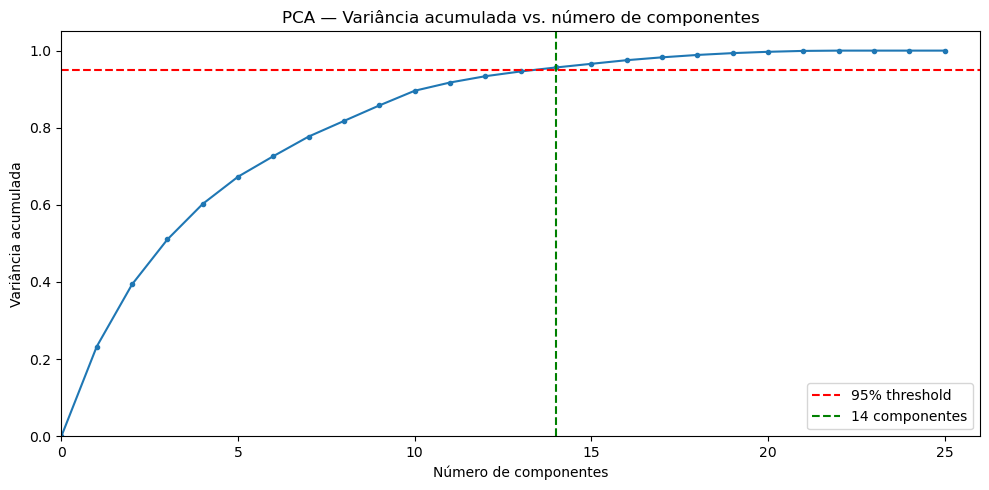

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

columns_to_drop = ['id', 'ip_version', 'expiration_id', 'src_mac', 'dst_mac', 'src_oui', 'dst_oui', 

    'src_ip_x', 'dst_ip_x', 'src_ip_y', 'dst_ip_y', 'src_port_x', 'dst_port_x', 'src_port_y', 'dst_port_y', 'vlan_id', 'tunnel_id', 'tcp.stream',

    'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms',

    'src2dst_first_seen_ms', 'src2dst_last_seen_ms',

    'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
    
    'label', 'flow_key']

df_model = df_final.drop(columns=columns_to_drop, errors='ignore')

columns_to_encode = df_model.select_dtypes(include=["object"]).columns.tolist()
for col in columns_to_encode:
    if col in df_final.columns:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna("unknown")
        df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model = df_model.fillna(0)

X = df_model
y = df_final["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 para ajustar o índice
print(f"Componentes necessárias para presevar pelo menos 95% da variância: {n_components_95} de {X.shape[1]}")
cumulative_variance = np.concatenate(([0], cumulative_variance))  # Adiciona um ponto inicial em 0

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'{n_components_95} componentes')
plt.xlabel("Número de componentes")
plt.ylabel("Variância acumulada")
plt.title("PCA — Variância acumulada vs. número de componentes")
plt.ylim(0, 1.05)
plt.xlim(0, X.shape[1]+1)
plt.legend()
plt.tight_layout()
plt.savefig("pca_variance.png")
plt.show()

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)

### Preparação dos modelos

Nesta secção, treinamos e comparamos três modelos diferentes:

   - **Random Forest**
   - **XG-Boost**
   - **Rede Neuronal MLP simples**

Para poder estudar o impacto da PCA tanto nos tempos de treino como no desempenho, aqui medido com o *F1-Score*, criamos set's de treino e teste para o dataset com PCA aplicado e sem PCA aplicado.

In [3]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

### RandomForest

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5, 
    class_weight="balanced", 
    n_jobs=-1, 
    random_state=42
)

rf.fit(X_train_pca, y_train)
rf_preds = rf.predict(X_test_pca)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

      benign       0.98      0.92      0.95     54341
   malicious       0.41      0.77      0.54      3967
         vpn       0.99      0.99      0.99      2851

    accuracy                           0.91     61159
   macro avg       0.79      0.89      0.83     61159
weighted avg       0.94      0.91      0.92     61159



### XG-Boost

In [5]:
from xgboost import XGBClassifier

le = LabelEncoder()
le.fit(["normal", "vpn"])
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb.fit(
    X_train_pca, y_train_enc,
    eval_set=[(X_test_pca, y_test_enc)],
    verbose=False
)

xgb_preds = le.inverse_transform(xgb.predict(X_test_pca))
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

      benign       0.96      0.99      0.98     54341
   malicious       0.89      0.40      0.55      3967
         vpn       0.97      0.98      0.97      2851

    accuracy                           0.96     61159
   macro avg       0.94      0.79      0.83     61159
weighted avg       0.95      0.96      0.95     61159



### Rede Neuronal MLP

In [6]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

mlp.fit(X_train_pca, y_train_enc)
mlp_preds = le.inverse_transform(mlp.predict(X_test_pca))
print(classification_report(y_test, mlp_preds))

              precision    recall  f1-score   support

      benign       0.93      1.00      0.96     54341
   malicious       0.74      0.01      0.02      3967
         vpn       0.95      0.97      0.96      2851

    accuracy                           0.93     61159
   macro avg       0.87      0.66      0.64     61159
weighted avg       0.92      0.93      0.90     61159



### Demonstração do impacto da PCA no tempo de treino e desempenho dos modelos 

Para podermos comparar o treino de modelos com PCA e sem o PCA, começamos por fazer fit de cada set em cada modelo, tendo em conta o tempo em que começa e acaba cada sessão se treino. Posteriormente comparamos os tempos de treino de cada modelo para cada set, tais como os respetivos *F1-Scores* e *accuracies*.

In [7]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
import time

models = {
    "Random Forest (full)": (rf,  X_train_full, y_train,     X_test_full, False),
    "Random Forest (PCA)":  (rf,  X_train_pca,  y_train,     X_test_pca,  False),
    "XGBoost (full)":       (xgb, X_train_full, y_train_enc, X_test_full, True),
    "XGBoost (PCA)":        (xgb, X_train_pca,  y_train_enc, X_test_pca,  True),
    "MLP (full)":           (mlp, X_train_full, y_train_enc, X_test_full, True),
    "MLP (PCA)":            (mlp, X_train_pca,  y_train_enc, X_test_pca,  True),
}

results = []
trained_models = {}
for name, (model, X_tr, y_tr, X_te, needs_decode) in models.items():
    print(f"A treinar {name}...")
    start = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - start

    trained_models[name] = (model, X_tr, X_te, needs_decode)

    preds = model.predict(X_te)

    if needs_decode:
        preds = le.inverse_transform(preds)

    results.append({
        "Model":          name,
        "F1 (weighted)":  round(f1_score(y_test, preds, average="weighted"), 4),
        "Accuracy":       round(accuracy_score(y_test, preds), 4),
        "Precision (weighted)":      round(precision_score(y_test, preds, average="weighted"), 4),
        "Recall (weighted)":         round(recall_score(y_test, preds, average="weighted"), 4),
        "Train Time (s)": round(elapsed, 2),
        "Features":       X_tr.shape[1]
    })

results_df = pd.DataFrame(results)
results_df.style.hide()

A treinar Random Forest (full)...
A treinar Random Forest (PCA)...
A treinar XGBoost (full)...
A treinar XGBoost (PCA)...
A treinar MLP (full)...
A treinar MLP (PCA)...


Model,F1 (weighted),Accuracy,Precision (weighted),Recall (weighted),Train Time (s),Features
Random Forest (full),0.925000,0.913300,0.945900,0.913300,12.430000,25
Random Forest (PCA),0.924600,0.913200,0.944800,0.913200,26.780000,14
XGBoost (full),0.950600,0.957300,0.953800,0.957300,5.470000,25
XGBoost (PCA),0.948100,0.955600,0.953100,0.955600,4.690000,14
MLP (full),0.943400,0.951300,0.947600,0.951300,6592.070000,25
MLP (PCA),0.900900,0.931300,0.918900,0.931300,2409.840000,14


Através da tabela de valores representada acima, conseguimos fazer certas observações:

   - Verificamos que globalmente, a utilização de PCA equivale a uma mínima redução na *accuracy*, no *F1-Score*, no *Recall* e na *Precision* de todos os modelos testado.

   - No que se refere ao modelo **Random Forest**, podemos observar que a utilização do PCA aumenta de forma significativa o tempo de treino do modelo, ocorrendo neste cada um aumento de 103% em relação com o treino sem PCA. Apesar de este comportamento parecer contraditório, este é esperado uma vez que a redução do número de features pode levar à geração de árvores mais profundas, resultando num tempo de treino mais elevado em modelos **Random Forest**.

   - Em relação ao **XGBoost** e ao **MLP**, o uso do PCA descreveu uma diminuição do tempo de treino, sendo esta diminuição muito mais expressiva no treino do **MLP**. Podemos observar uma diminuição de cerca de 19.1% no **XGBoost** e cerca de 40.9% no **MLP**.

### Explicabilidade (SHAP)

Usamos ainda o *SHAP* para determinar quais das features originais são as mais decisivas para o modelo.

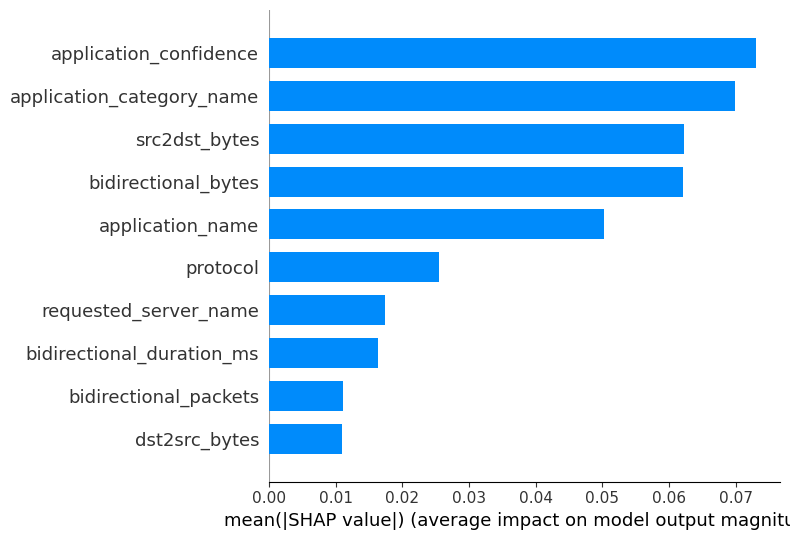

In [8]:
import shap

rf.fit(X_train_full, y_train)
X_test_numpy = np.array(X_test_full, dtype=np.float32)

sample_idx = np.random.choice(X_test_numpy.shape[0], size=5000, replace=False)
X_shap_sample = X_test_numpy[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap_sample)
shap_values = shap_values[:, :, 1]
feature_names = df_model.columns.tolist()

shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, plot_type="bar", max_display=10)

Pelo gráfico descrito acima conseguimos observar que as 5 features mais decisivas para os modelos conseguirem identificar o tráfego são:

   - **application_confidence**
   - **application_category_name**
   - **bidirectional_bytes**
   - **src2dst_bytes**
   - **application_name**

## Deteção de Anomalias com Aprendizagem Não-Supervisionada

Para a deteção de anomalias nós usamos um modelo Isolation Forest em aprendizagem não-supervisionada para criar um perfil do tráfego normal da rede. Após o treino e previsão do modelo, visualizamos os dados com t-SNE para exibir os resultados em clusters.

In [11]:
from sklearn.ensemble import IsolationForest

# lembrar de apagar as labels antes de treinar e fazer a prediction

mask_normal = df_final["label"] == "benign"

X_normal = X[mask_normal]
print(X.shape, X_normal.shape)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_normal)
anomaly_preds = iso.predict(X)
anomaly_scores = iso.decision_function(X)

df_final["anomaly"] = anomaly_preds
df_final["anomaly_score"] = anomaly_scores

print(f"Anomalias detectadas:  {(anomaly_preds == -1).sum()}")
print(f"Normais detectados:    {(anomaly_preds == 1).sum()}")

(305795, 25) (271706, 25)
Anomalias detectadas:  43054
Normais detectados:    262741


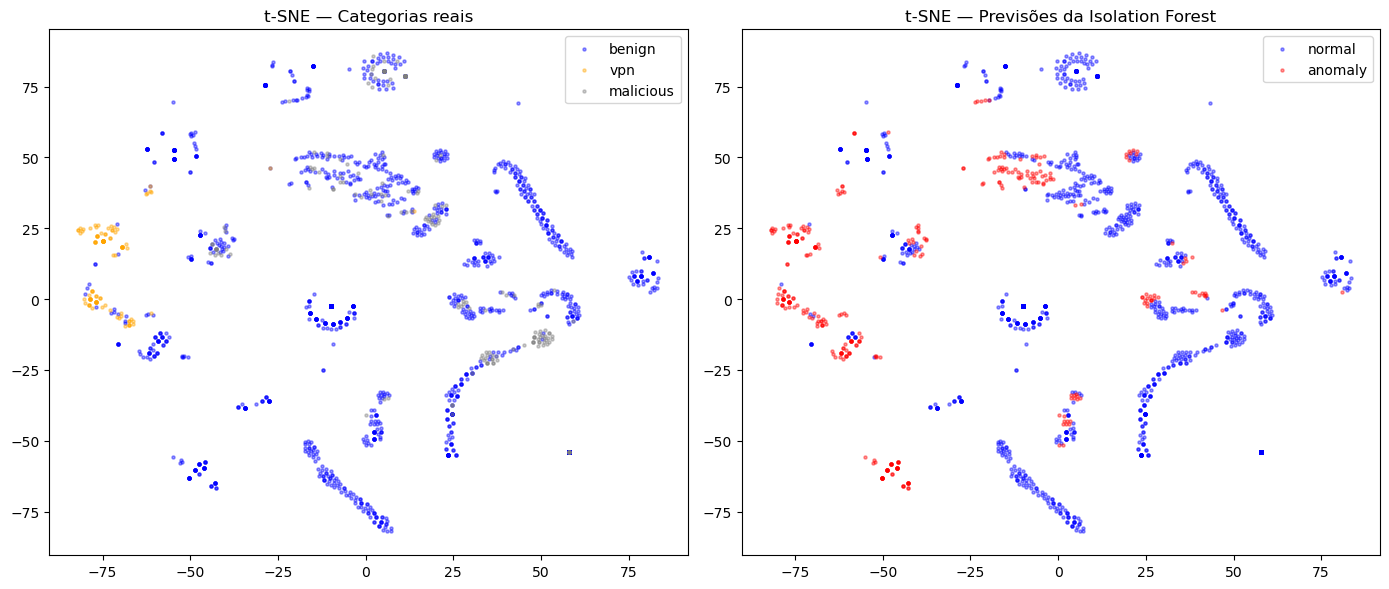

In [12]:
from sklearn.manifold import TSNE

sample_size = 2500
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx]
labels_sample = df_final["label"].values[idx]
anomaly_sample = df_final["anomaly"].values[idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42
)
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colors = {"benign": "blue", "vpn": "orange", "malicious": "gray"}
for label in ["benign", "vpn", "malicious"]:
    mask = labels_sample == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[label], label=label, alpha=0.4, s=5)
plt.title("t-SNE — Categorias reais")
plt.legend()

plt.subplot(1, 2, 2)
colors_anomaly = {1: "blue", -1: "red"}
for val, label in [(1, "normal"), (-1, "anomaly")]:
    mask = anomaly_sample == val
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors_anomaly[val], label=label, alpha=0.4, s=5)
plt.title("t-SNE — Previsões da Isolation Forest")
plt.legend()

plt.tight_layout()
plt.savefig("tsne_visualization.png", dpi=150)
plt.show()

Através dos gráficos acima apresentados, conseguimos verificar que o modelo conseguiu identificar corretamente todas as instâncias de tráfego **VPN/Tor** como anomalias, observando que todas as instâncias deste tráfego encontra-se focado em clusters. No entanto o modelo têm dificuldades em separar o tráfego malicioso do tráfego benigno. Podemos observar que poucas são as instâncias de tráfego malicioso que são corretamente identificadas como anomalias e observamos também várias instâncias de tráfego benigno incorretamente identificadas como anomalias.

## Regras IDS para Suricata

Com base na importância de features descrita pelo SHAP, nós criamos 2 regras Suricata: uma com base na quantidade de bytes (`bidirectional_bytes`, `src2dst_bytes` e `dst2src_bytes`) e uma com base no protocolo (`protocol`) e na duração (`bidirectional_duration_ms`).

### Regra 1

A análise do SHAP demonstra que a quantidade de bytes têm elevada importância na identificação de tráfego VPN/Tor. Nesta regra temos como base a assunção que o tráfego VPN/Tor é caracterizado, em modo geral, por `flows` simétricos de grandes dimensões, ao invés do tráfego HTTPS normal que é caracterizado por `flows` assimétricos.

```
alert tls any any -> any any (
    msg:"Possible VPN tunnel - high bidirectional TLS traffic";

    flow:established;

    flow.bytes_toserver:>1000000;
    flow.bytes_toclient:>1000000;

    detection_filter:track by_src, count 3, seconds 120;

    sid:9000001;
    rev:1;
    classtype:policy-violation;
)
```
Explicação da regra:

   - **flow:established** - faz com que a regra só inspecione conexões TLS completas.

   - **flow.bytes_toserver:>1000000** e **flow.bytes_toclient:>1000000** - faz a regra só avisar caso haja a troca de pelo menos 1MB entre cliente e servidor e vice-versa.

   - **detection_filter:track by_src, count 3, seconds 120;** - isto faz com que a regra só crie um alerta se este comportamento ocorrer um mínimo de 3 vezes em 120 segundos, diminuindo os falsos positivos. 

### Regra 2

A análise do SHAP demonstra que outra métrica identificadora é o duração do tráfego em certas portas geralmente usadas por VPN/Tor. Neste caso usamos a ideia que o tráfego VPN/Tor é muito comum em certas portas do protcolo UDP e que este tráfego têm, em geral, elevada duração. 

```
alert udp any any -> any [1194,500,4500,51820] (
    msg:"Possible VPN tunnel - sustained traffic on common VPN ports";

    threshold:type threshold, track by_src, count 20, seconds 10;

    sid:9000002;
    rev:1;
    classtype:policy-violation;
)
```
Explicação da regra:

   - **threshold:type threshold, track by_src, count 20, seconds 10;** - faz com que a regra só crie alerta se um certo IP mandar um mínimo de 20 pacotes no espaço de 10 segundos para as portas descritas no header.